# Корпуса: MLP, глубина vs ширина

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)

**Тема 24:** исследовать влияние числа слоев и нейронов на аппроксимацию, сравнить shallow и deep сети при одинаковом числе параметров и построить heatmap `ширина × глубина -> качество`.

Основные датасеты -- **MNIST** и **Fashion-MNIST**. Архитектуру специально не усложняю: `Linear + ReLU` _(цель -- сравнить глубину и ширину, не хочу вводить лишние переменные в это уравнение)_.

Единственная регуляризация -- фиксированный `weight decay`, т.к. он обязателен по общей части задания и при этом не меняет саму архитектуру.


## Маленькая теоретическая справка

### Глубина и ширина

Пусть сеть имеет `d` скрытых слоев одинаковой ширины `w`. Для входа из 784 пикселей и 10 классов:

$$
    P(d, w)
    = (784 + 1) \cdot w + (d - 1) \cdot (w + 1) \cdot w + (w + 1) \cdot 10.
$$

Поэтому сравнение при одинаковой ширине -- не то же самое, что сравнение при одинаковой сложности: при росте глубины число параметров быстро растет из-за матриц `w × w`. **Буду сравнивать и то, и то.**

### Теорема об универсальной аппроксимации

Классическая теорема об универсальной аппроксимации говорит, что feed-forward сеть с одним скрытым слоем и достаточно большим числом нейронов при подходящей нелинейной активации способна сколь угодно точно приблизить непрерывную функцию на компактном множестве.

**Почему это -- не панацея:**

- теорема утверждает существование весов, но не говорит, как их найти;
- она не ограничивает требуемую ширину -- shallow-сеть может потребовать очень много нейронов;
- она не гарантирует хорошее обобщение;
- композиционные функции часто представляются глубокими сетями параметрически эффективнее;
- очень глубокая plain MLP без residual connections может, наоборот, хуже оптимизироваться.


In [1]:
import gc
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import FashionMNIST, MNIST


SEED = 143
CACHE_DIR = Path.home() / ".cache" / "mlstart_hw03"

cwd = Path.cwd().resolve()
if (cwd / "hws").exists():
    HWS_DIR = cwd / "hws"
elif cwd.name == "notebooks" and cwd.parent.name == "hws":
    HWS_DIR = cwd.parent
else:
    HWS_DIR = cwd

OUTPUT_DIR = HWS_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

VAL_SIZE = 10_000
GRID_TRAIN_SIZE = 20_000
BATCH_SIZE = 128
GRID_EPOCHS = 3
CURVE_EPOCHS = 10
MATCHED_EPOCHS = 3
CV_EPOCHS = 3
FINAL_EPOCHS = 8
LR = 1e-3
WEIGHT_DECAY = 1e-4

DEPTHS = [1, 2, 3, 5, 10, 20, 50, 100]
WIDTHS = [8, 16, 32, 64, 128, 256]
PARAMETER_BUDGETS = [50_000, 150_000, 500_000]
MATCHED_DEPTHS = [1, 2, 5, 10, 20, 50, 100]
CURVE_CONFIGS = [(1, 256), (5, 128), (20, 64), (100, 32)]

DATASET_STATS = {
    "MNIST": (0.1307, 0.3081),
    "Fashion-MNIST": (0.2860, 0.3530),
}

sns.set_theme(style="whitegrid")
print("device:", DEVICE)


device: mps


Достаточно широкая сетка: от 1 до 100 скрытых слоев и от 8 до 256 нейронов. В sweep фиксирую optimizer, learning rate, число эпох и regularization, чтобы менялись именно `depth` и `width`.

Official test до финала не трогаю. Для sweep используется один и тот же стратифицированный train/validation split, а выбранная архитектура дополнительно проверяется 5-fold CV.


In [2]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_dataset(dataset_class, dataset_name):
    mean, std = DATASET_STATS[dataset_name]
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((mean,), (std,)),
    ])

    train_dataset = dataset_class(CACHE_DIR, train=True, download=True, transform=transform)
    test_dataset = dataset_class(CACHE_DIR, train=False, download=True, transform=transform)
    targets = np.asarray(train_dataset.targets)

    train_index, val_index = train_test_split(
        np.arange(len(targets)),
        test_size=VAL_SIZE,
        stratify=targets,
        random_state=SEED,
    )

    grid_index, _ = train_test_split(
        train_index,
        train_size=GRID_TRAIN_SIZE,
        stratify=targets[train_index],
        random_state=SEED,
    )

    return {
        "all_train": train_dataset,
        "train": Subset(train_dataset, train_index),
        "grid": Subset(train_dataset, grid_index),
        "val": Subset(train_dataset, val_index),
        "test": test_dataset,
        "targets": targets,
        "train_index": train_index,
        "grid_index": grid_index,
        "val_index": val_index,
        "classes": train_dataset.classes,
    }


def make_loader(dataset, shuffle=False):
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator if shuffle else None,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


In [3]:
class MLP(nn.Module):
    def __init__(self, depth, width, n_classes=10):
        super().__init__()

        layers = [nn.Flatten()]
        in_features = 28 * 28

        for _ in range(depth):
            layers.append(nn.Linear(in_features, width))
            layers.append(nn.ReLU())
            in_features = width

        layers.append(nn.Linear(in_features, n_classes))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def parameter_count(depth, width):
    return (784 + 1) * width + (depth - 1) * (width + 1) * width + (width + 1) * 10


def width_for_budget(depth, budget):
    widths = np.arange(4, 2049)
    counts = np.array([parameter_count(depth, width) for width in widths])
    return int(widths[np.abs(counts - budget).argmin()])


## Train loop

Optimizer, learning rate, loss, `weight_decay` и число эпох фиксированы внутри каждого типа сравнения.

Early stopping в sweep не использую: иначе разные архитектуры фактически получили бы разный training budget.


In [4]:
def classification_metrics(y_true, y_pred):
    return {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    y_true = []
    y_pred = []
    probabilities = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            total_loss += loss.item() * len(y_batch)
            probs = torch.softmax(logits, dim=1)
            y_true.append(y_batch.cpu().numpy())
            y_pred.append(logits.argmax(dim=1).cpu().numpy())
            probabilities.append(probs.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    probabilities = np.concatenate(probabilities)
    metrics = classification_metrics(y_true, y_pred)
    metrics.update({
        "loss": total_loss / len(loader.dataset),
        "y_true": y_true,
        "y_pred": y_pred,
        "probabilities": probabilities,
    })
    return metrics


def fit_model(depth, width, train_dataset, val_dataset, epochs):
    set_seed()
    model = MLP(depth, width).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.CrossEntropyLoss()
    train_loader = make_loader(train_dataset, shuffle=True)
    val_loader = make_loader(val_dataset)

    history = []
    started = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        train_true = []
        train_pred = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(y_batch)
            train_true.append(y_batch.cpu().numpy())
            train_pred.append(logits.argmax(dim=1).detach().cpu().numpy())

        train_true = np.concatenate(train_true)
        train_pred = np.concatenate(train_pred)
        train_metrics = classification_metrics(train_true, train_pred)
        val_metrics = evaluate(model, val_loader, loss_fn)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss / len(train_dataset),
            "train_balanced_accuracy": train_metrics["balanced_accuracy"],
            "val_loss": val_metrics["loss"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_macro_precision": val_metrics["macro_precision"],
            "val_macro_recall": val_metrics["macro_recall"],
        })

    return model, pd.DataFrame(history), time.perf_counter() - started


def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## Ширина × глубина -- MNIST


In [5]:
def architecture_sweep(dataset_name, data):
    rows = []

    for depth in DEPTHS:
        for width in WIDTHS:
            print(f"{dataset_name}: depth={depth}, width={width}")
            model, history, elapsed = fit_model(depth, width, data["grid"], data["val"], GRID_EPOCHS)
            last = history.iloc[-1]
            rows.append({
                "dataset": dataset_name,
                "depth": depth,
                "width": width,
                "parameters": count_parameters(model),
                "val_balanced_accuracy": last.val_balanced_accuracy,
                "val_macro_f1": last.val_macro_f1,
                "val_macro_precision": last.val_macro_precision,
                "val_macro_recall": last.val_macro_recall,
                "val_loss": last.val_loss,
                "train_time_sec": elapsed,
            })
            pd.DataFrame(rows).to_csv(OUTPUT_DIR / f"{dataset_name.lower().replace('-', '_')}_architecture_results.csv", index=False)
            del model
            cleanup_memory()

    return pd.DataFrame(rows)


mnist_data = load_dataset(MNIST, "MNIST")
mnist_grid_results = architecture_sweep("MNIST", mnist_data)
mnist_grid_results.sort_values("val_balanced_accuracy", ascending=False).head(10)


MNIST: depth=1, width=8
MNIST: depth=1, width=16
MNIST: depth=1, width=32
MNIST: depth=1, width=64
MNIST: depth=1, width=128
MNIST: depth=1, width=256
MNIST: depth=2, width=8
MNIST: depth=2, width=16
MNIST: depth=2, width=32
MNIST: depth=2, width=64
MNIST: depth=2, width=128
MNIST: depth=2, width=256
MNIST: depth=3, width=8
MNIST: depth=3, width=16
MNIST: depth=3, width=32
MNIST: depth=3, width=64
MNIST: depth=3, width=128
MNIST: depth=3, width=256
MNIST: depth=5, width=8
MNIST: depth=5, width=16
MNIST: depth=5, width=32
MNIST: depth=5, width=64
MNIST: depth=5, width=128
MNIST: depth=5, width=256
MNIST: depth=10, width=8
MNIST: depth=10, width=16
MNIST: depth=10, width=32
MNIST: depth=10, width=64
MNIST: depth=10, width=128
MNIST: depth=10, width=256
MNIST: depth=20, width=8
MNIST: depth=20, width=16
MNIST: depth=20, width=32
MNIST: depth=20, width=64
MNIST: depth=20, width=128
MNIST: depth=20, width=256
MNIST: depth=50, width=8
MNIST: depth=50, width=16
MNIST: depth=50, width=32
MNIST

,dataset,depth,width,parameters,val_balanced_accuracy,val_macro_f1,val_macro_precision,val_macro_recall,val_loss,train_time_sec
17,MNIST,3,256,335114,0.954990,0.954935,0.955598,0.954990,0.148289,4.279837
11,MNIST,2,256,269322,0.954703,0.954745,0.955392,0.954703,0.146973,4.114512
5,MNIST,1,256,203530,0.954033,0.954042,0.954297,0.954033,0.158024,3.876394
23,MNIST,5,256,466698,0.951312,0.951249,0.952093,0.951312,0.164403,4.529755
16,MNIST,3,128,134794,0.950466,0.950484,0.951009,0.950466,0.162096,4.298293
10,MNIST,2,128,118282,0.949654,0.949607,0.949922,0.949654,0.167278,4.013176
4,MNIST,1,128,101770,0.944032,0.943892,0.944163,0.944032,0.190991,3.864746
22,MNIST,5,128,167818,0.942406,0.942334,0.943083,0.942406,0.185224,4.468898
9,MNIST,2,64,55050,0.938501,0.938245,0.938586,0.938501,0.209658,3.912312
15,MNIST,3,64,59210,0.935313,0.935087,0.935543,0.935313,0.210840,4.452626


In [19]:
def plot_architecture_heatmaps(results, dataset_name, slug):
    for metric, title in [
        ("val_balanced_accuracy", "balanced accuracy"),
        ("val_macro_f1", "macro-F1"),
    ]:
        matrix = results.pivot(index="depth", columns="width", values=metric)
        plt.figure(figsize=(9, 7))
        sns.heatmap(matrix, annot=True, fmt=".3f", cmap="viridis")
        plt.title(f"{dataset_name} -- width × depth -> {title}")
        plt.xlabel("Width")
        plt.ylabel("Depth")
        plt.savefig(OUTPUT_DIR / f"{slug}_{metric}_heatmap.png", dpi=160, bbox_inches="tight")
        plt.show()

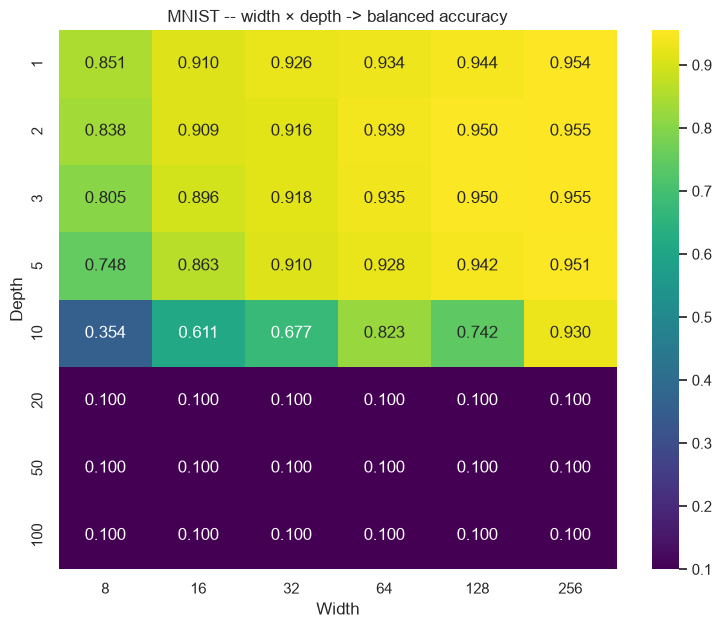

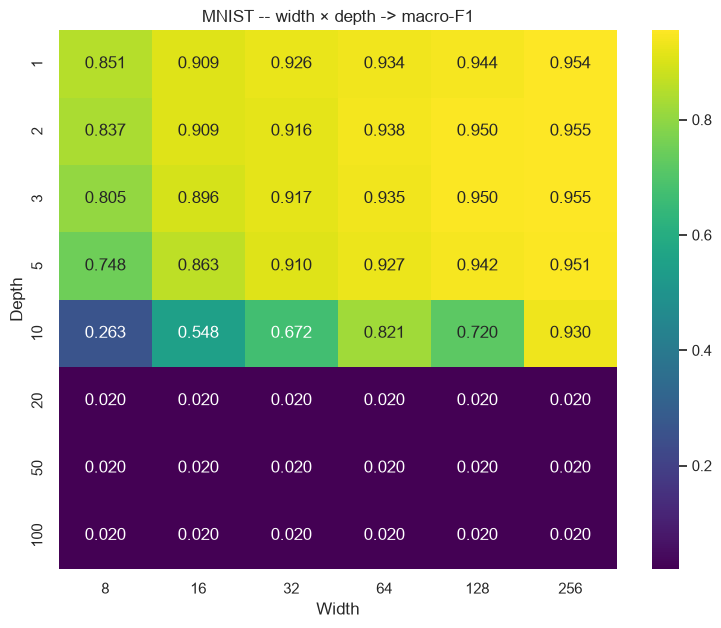

In [20]:
plot_architecture_heatmaps(mnist_grid_results, "MNIST", "mnist")

Здесь интересно смотреть не только на максимум, но и на форму heatmap: если после некоторой глубины качество систематически падает при разных ширинах. _Связываю это с затуханием градиентов_.

У неглубоких же сетей выходим на плато по ширине, падения не наблюдаю.


In [21]:
def plot_depth_width(results, dataset_name, slug):
    plt.figure(figsize=(9, 5))
    for width in WIDTHS:
        part = results[results.width == width]
        plt.plot(part.depth, part.val_balanced_accuracy, marker="o", label=f"w={width}")
    plt.xscale("log")
    plt.xlabel("Depth, log scale")
    plt.ylabel("Validation balanced accuracy")
    plt.title(f"{dataset_name} -- качество vs глубина")
    plt.legend(ncol=2)
    plt.savefig(OUTPUT_DIR / f"{slug}_balanced_accuracy_vs_depth.png", dpi=160, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(9, 5))
    for depth in [1, 5, 20, 100]:
        part = results[results.depth == depth]
        plt.plot(part.width, part.val_balanced_accuracy, marker="o", label=f"d={depth}")
    plt.xscale("log", base=2)
    plt.xlabel("Width, log2 scale")
    plt.ylabel("Validation balanced accuracy")
    plt.title(f"{dataset_name} -- качество vs ширина")
    plt.legend()
    plt.savefig(OUTPUT_DIR / f"{slug}_balanced_accuracy_vs_width.png", dpi=160, bbox_inches="tight")
    plt.show()

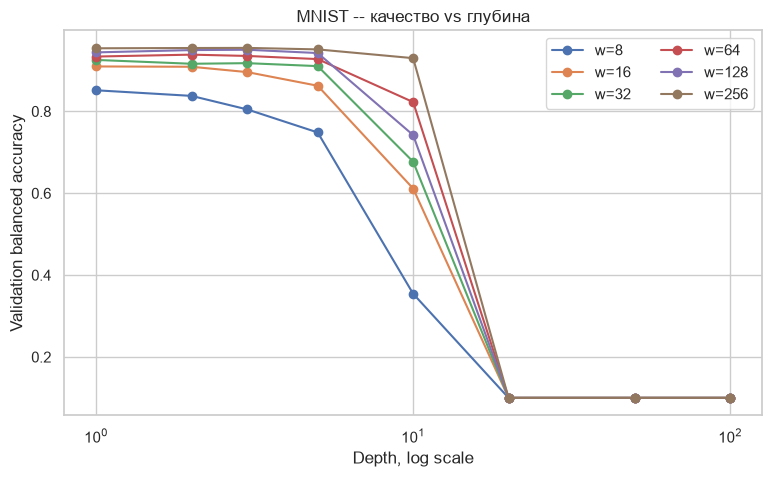

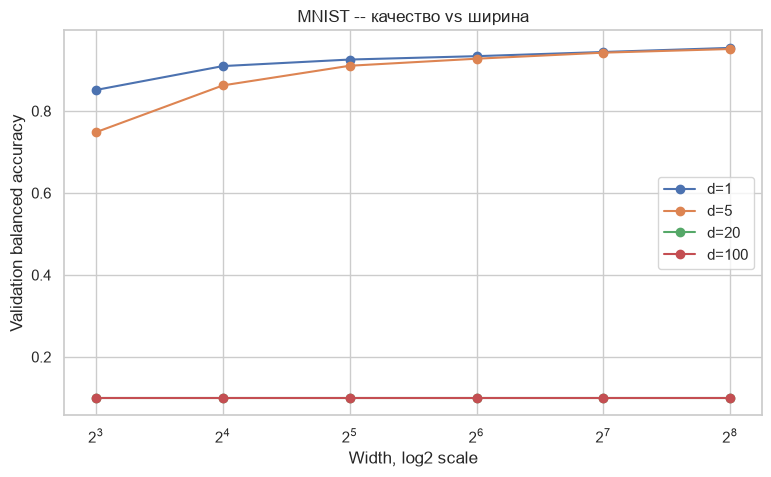

In [22]:
plot_depth_width(mnist_grid_results, "MNIST", "mnist")

Видим, что при увеличении глубины наступает момент, когда каждая из моделей сильно проседает по метрике, в то время как с шириной такого не происходит.

## Ширина × глубина -- Fashion-MNIST


In [8]:
fashion_data = load_dataset(FashionMNIST, "Fashion-MNIST")
fashion_grid_results = architecture_sweep("Fashion-MNIST", fashion_data)
fashion_grid_results.sort_values("val_balanced_accuracy", ascending=False).head(10)


Fashion-MNIST: depth=1, width=8
Fashion-MNIST: depth=1, width=16
Fashion-MNIST: depth=1, width=32
Fashion-MNIST: depth=1, width=64
Fashion-MNIST: depth=1, width=128
Fashion-MNIST: depth=1, width=256
Fashion-MNIST: depth=2, width=8
Fashion-MNIST: depth=2, width=16
Fashion-MNIST: depth=2, width=32
Fashion-MNIST: depth=2, width=64
Fashion-MNIST: depth=2, width=128
Fashion-MNIST: depth=2, width=256
Fashion-MNIST: depth=3, width=8
Fashion-MNIST: depth=3, width=16
Fashion-MNIST: depth=3, width=32
Fashion-MNIST: depth=3, width=64
Fashion-MNIST: depth=3, width=128
Fashion-MNIST: depth=3, width=256
Fashion-MNIST: depth=5, width=8
Fashion-MNIST: depth=5, width=16
Fashion-MNIST: depth=5, width=32
Fashion-MNIST: depth=5, width=64
Fashion-MNIST: depth=5, width=128
Fashion-MNIST: depth=5, width=256
Fashion-MNIST: depth=10, width=8
Fashion-MNIST: depth=10, width=16
Fashion-MNIST: depth=10, width=32
Fashion-MNIST: depth=10, width=64
Fashion-MNIST: depth=10, width=128
Fashion-MNIST: depth=10, width=256

,dataset,depth,width,parameters,val_balanced_accuracy,val_macro_f1,val_macro_precision,val_macro_recall,val_loss,train_time_sec
11,Fashion-MNIST,2,256,269322,0.8665,0.867642,0.869955,0.8665,0.363750,4.100874
17,Fashion-MNIST,3,256,335114,0.8630,0.863509,0.865474,0.8630,0.375913,4.293174
16,Fashion-MNIST,3,128,134794,0.8616,0.861883,0.862618,0.8616,0.377686,4.177709
5,Fashion-MNIST,1,256,203530,0.8600,0.861961,0.866374,0.8600,0.383020,4.067834
23,Fashion-MNIST,5,256,466698,0.8537,0.852103,0.855007,0.8537,0.403577,4.582847
3,Fashion-MNIST,1,64,50890,0.8507,0.851562,0.854561,0.8507,0.410415,4.011325
4,Fashion-MNIST,1,128,101770,0.8507,0.852220,0.857113,0.8507,0.403416,4.030216
10,Fashion-MNIST,2,128,118282,0.8507,0.852130,0.857553,0.8507,0.399923,3.978850
2,Fashion-MNIST,1,32,25450,0.8491,0.848956,0.848966,0.8491,0.422874,4.191066
22,Fashion-MNIST,5,128,167818,0.8481,0.846230,0.850060,0.8481,0.421338,4.524294


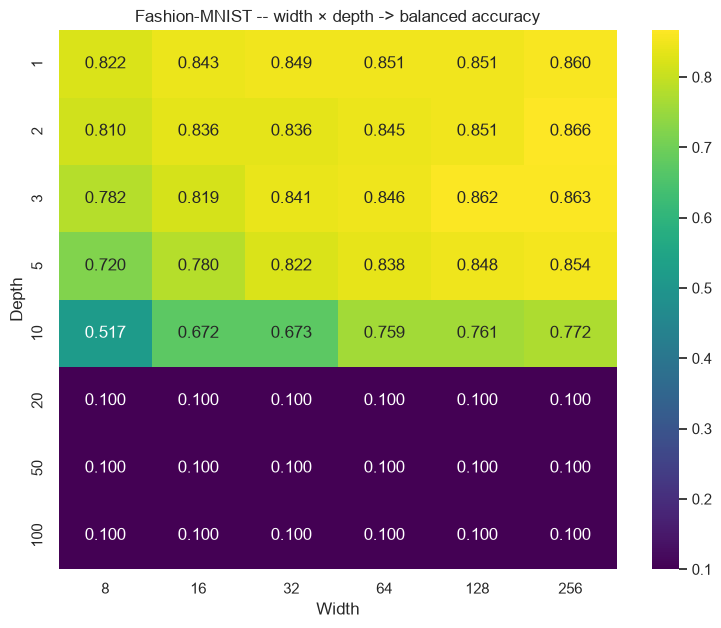

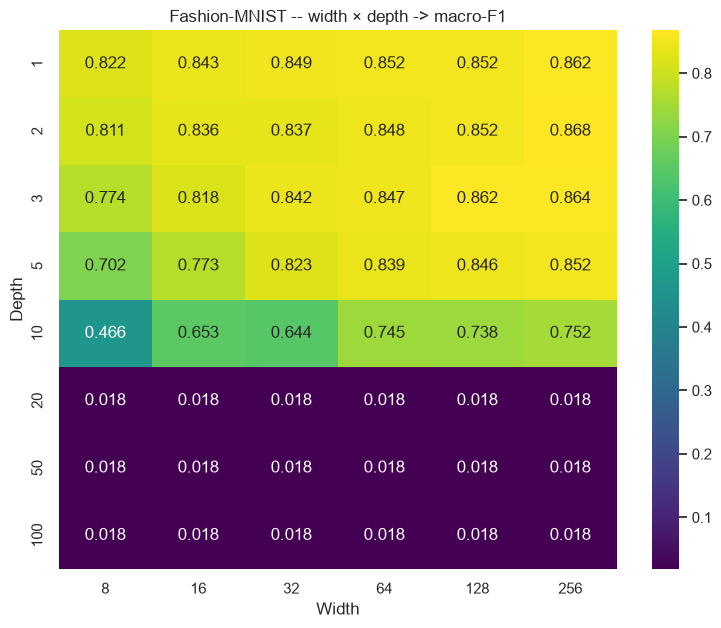

In [24]:
plot_architecture_heatmaps(fashion_grid_results, "Fashion-MNIST", "fashion")

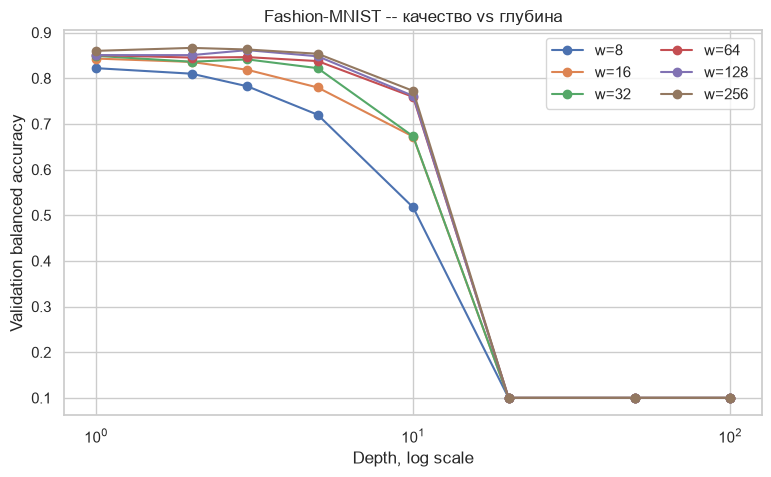

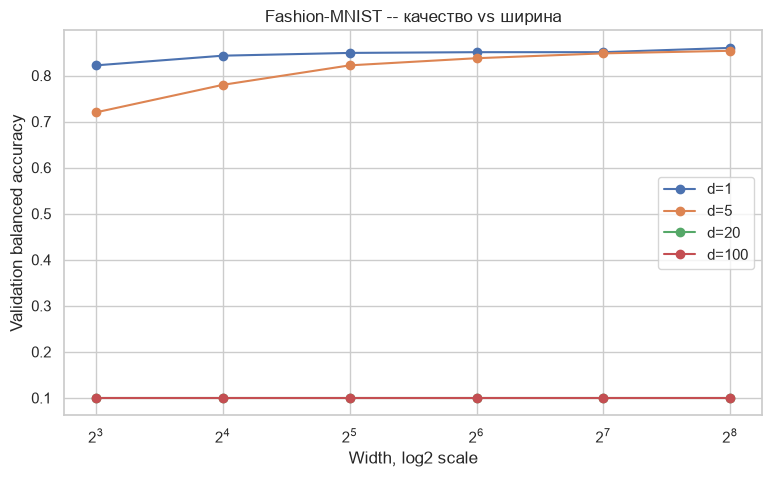

In [23]:
plot_depth_width(fashion_grid_results, "Fashion-MNIST", "fashion")

`Fashion-MNIST` сложнее именно по похожим классам одежды, поэтому абсолютное качество ожидаемо ниже _(см. матрицы -- метрики у `Fashion` пониже в абсолютном значении, но их распределения довольно похожи)_. 

## Learning curves


Для отдельных мною избранных архитектур отдельно строю learning curves на более длинном обучении _(для всех строить больно)_ .

На одном графике обязательно показываю **train и validation loss**: по их расхождению видно начало переобучения. Аналогично рядом сравниваю train/validation balanced accuracy.


In [10]:
def run_learning_curves(dataset_name, data):
    histories = {}
    for depth, width in CURVE_CONFIGS:
        print(f"{dataset_name}: depth={depth}, width={width}")
        model, history, elapsed = fit_model(depth, width, data["grid"], data["val"], CURVE_EPOCHS)
        history["depth"] = depth
        history["width"] = width
        history["train_time_sec"] = elapsed
        histories[(depth, width)] = history
        del model
    cleanup_memory()
    return histories

mnist_histories = run_learning_curves("MNIST", mnist_data)


MNIST: depth=1, width=256
MNIST: depth=5, width=128
MNIST: depth=20, width=64
MNIST: depth=100, width=32


In [25]:
def plot_learning_curves(histories, dataset_name, slug):
    plt.figure(figsize=(10, 6))
    for (depth, width), history in histories.items():
        label = f"d={depth}, w={width}"
        plt.plot(history.epoch, history.train_loss, marker="o", label=f"{label} train")
        plt.plot(history.epoch, history.val_loss, marker="o", linestyle="--", label=f"{label} val")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy")
    plt.title(f"{dataset_name} -- train/validation loss")
    plt.legend(ncol=2, fontsize=8)
    plt.savefig(OUTPUT_DIR / f"{slug}_learning_curve_loss.png", dpi=160, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 6))
    for (depth, width), history in histories.items():
        label = f"d={depth}, w={width}"
        plt.plot(history.epoch, history.train_balanced_accuracy, marker="o", label=f"{label} train")
        plt.plot(history.epoch, history.val_balanced_accuracy, marker="o", linestyle="--", label=f"{label} val")
    plt.xlabel("Epoch")
    plt.ylabel("Balanced accuracy")
    plt.title(f"{dataset_name} -- train/validation balanced accuracy")
    plt.legend(ncol=2, fontsize=8)
    plt.savefig(OUTPUT_DIR / f"{slug}_learning_curve_balanced_accuracy.png", dpi=160, bbox_inches="tight")
    plt.show()


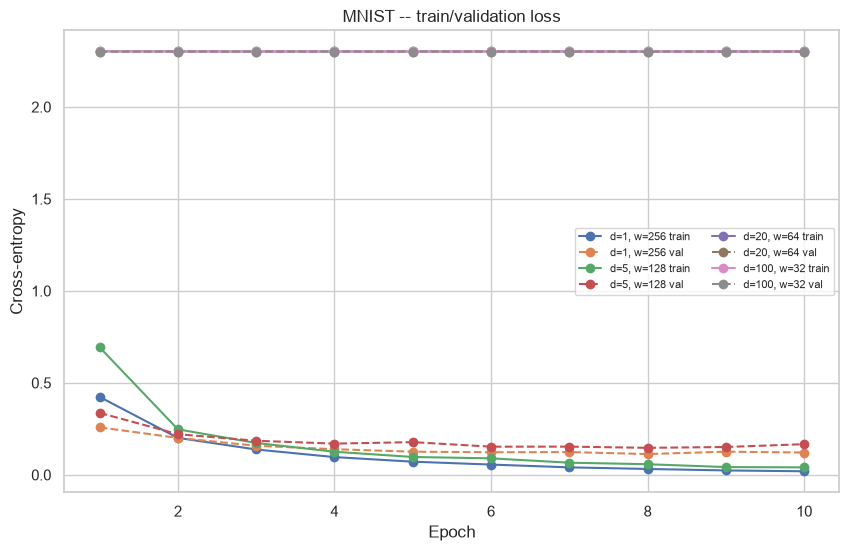

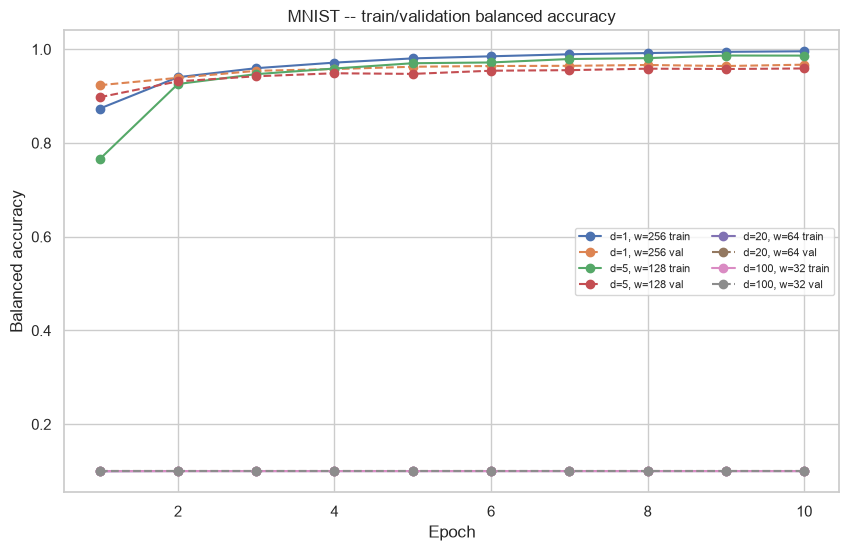

In [26]:
plot_learning_curves(mnist_histories, "MNIST", "mnist")

Fashion-MNIST: depth=1, width=256
Fashion-MNIST: depth=5, width=128
Fashion-MNIST: depth=20, width=64
Fashion-MNIST: depth=100, width=32


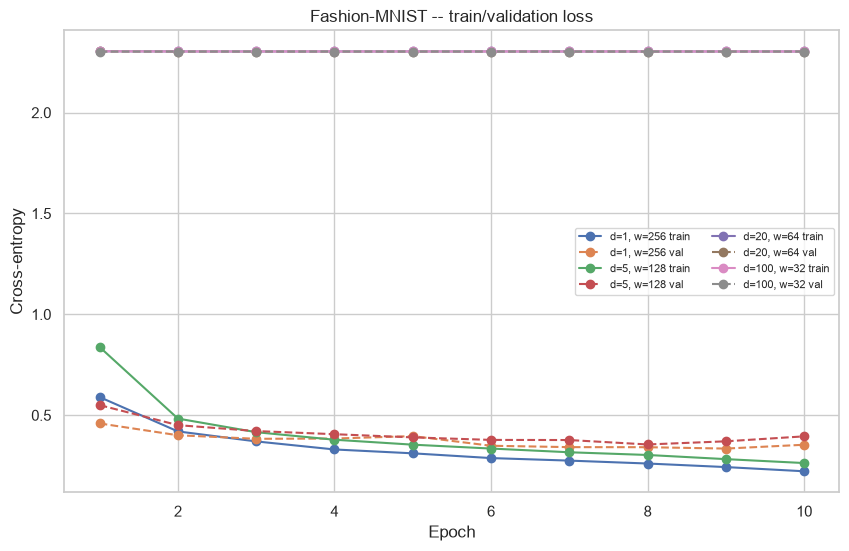

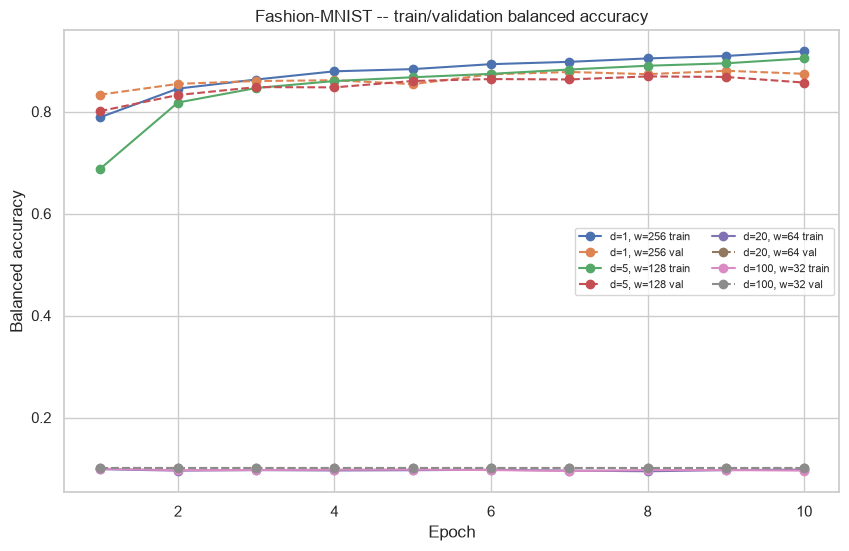

In [ ]:
fashion_histories = run_learning_curves("Fashion-MNIST", fashion_data)

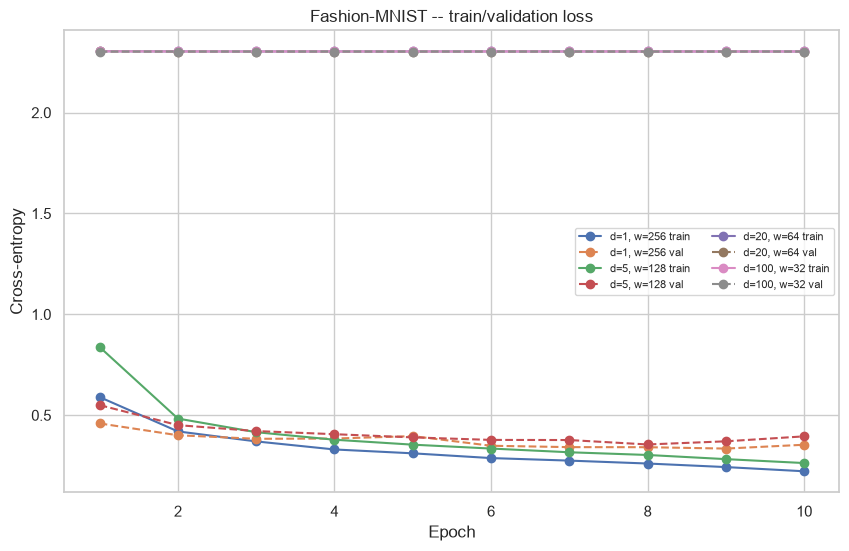

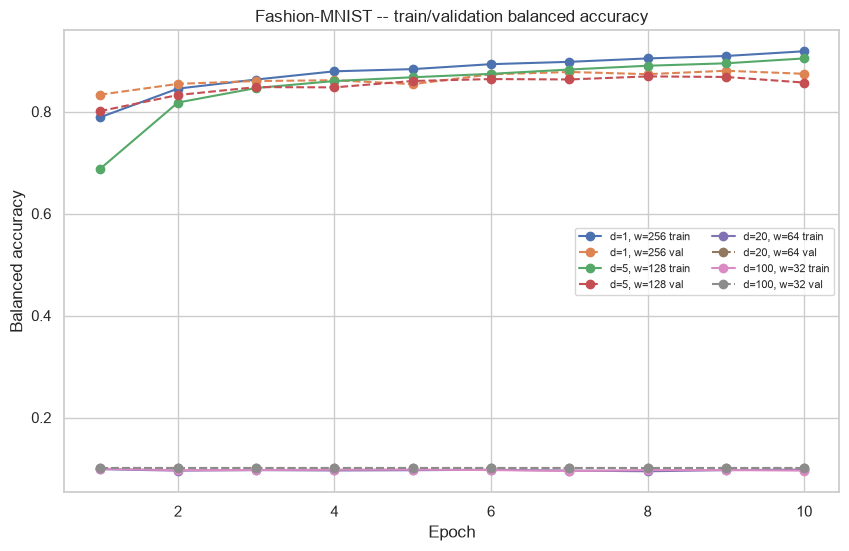

In [27]:
plot_learning_curves(fashion_histories, "Fashion-MNIST", "fashion")

Графики адекватны.

## Shallow vs deep при одинаковом числе параметров


Теперь глубина меняется при фиксированном **бюджете параметров** -- для каждого `depth` ширина выбирается из формулы числа параметров.


In [13]:
def parameter_matched_experiment(dataset_name, data):
    rows = []
    for budget in PARAMETER_BUDGETS:
        for depth in MATCHED_DEPTHS:
            width = width_for_budget(depth, budget)
            model, history, elapsed = fit_model(depth, width, data["grid"], data["val"], MATCHED_EPOCHS)
            last = history.iloc[-1]
            rows.append({
                "dataset": dataset_name,
                "budget": budget,
                "depth": depth,
                "width": width,
                "parameters": count_parameters(model),
                "val_balanced_accuracy": last.val_balanced_accuracy,
                "val_macro_f1": last.val_macro_f1,
                "train_time_sec": elapsed,
            })
            del model
    cleanup_memory()
    return pd.DataFrame(rows)

mnist_matched = parameter_matched_experiment("MNIST", mnist_data)
fashion_matched = parameter_matched_experiment("Fashion-MNIST", fashion_data)
mnist_matched.to_csv(OUTPUT_DIR / "mnist_parameter_matched.csv", index=False)
fashion_matched.to_csv(OUTPUT_DIR / "fashion_parameter_matched.csv", index=False)


In [28]:
def plot_parameter_matched(results, dataset_name, slug):
    plt.figure(figsize=(9, 5))
    for budget in PARAMETER_BUDGETS:
        part = results[results.budget == budget]
        plt.plot(part.depth, part.val_balanced_accuracy, marker="o", label=f"budget≈{budget:,}")
    plt.xscale("log")
    plt.xlabel("Depth, log scale")
    plt.ylabel("Validation balanced accuracy")
    plt.title(f"{dataset_name} -- shallow vs deep при сопоставимом числе параметров")
    plt.legend()
    plt.savefig(OUTPUT_DIR / f"{slug}_parameter_matched_balanced_accuracy.png", dpi=160, bbox_inches="tight")
    plt.show()

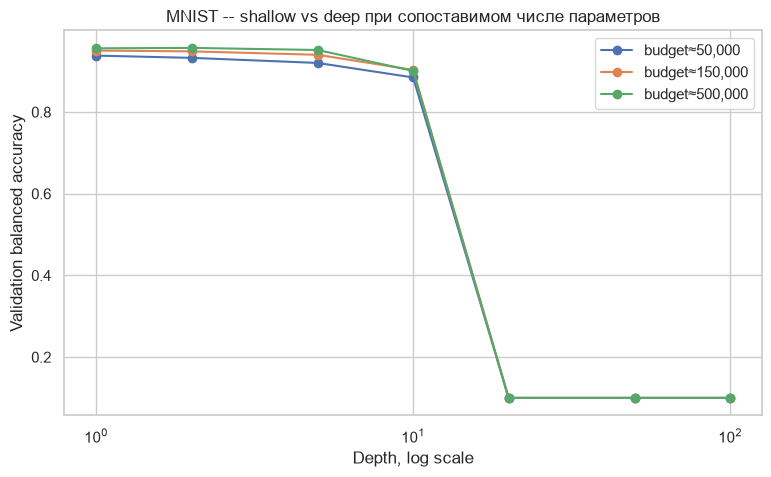

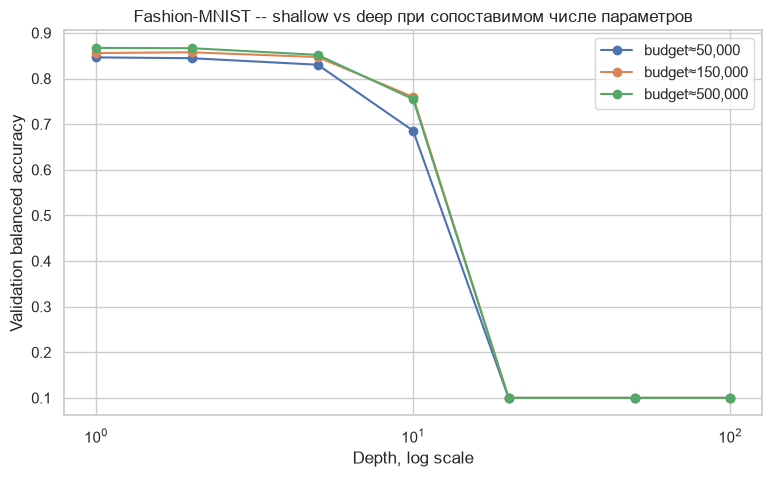

In [29]:
plot_parameter_matched(mnist_matched, "MNIST", "mnist")
plot_parameter_matched(fashion_matched, "Fashion-MNIST", "fashion")

Видим аналогичную ситуацию: слишком большая глубина -- плохо.

Но при адекватных ее значениях все хорошо.

## 5-fold cross-validation выбранной архитектуры


Один hold-out split удобен для большого sweep, но сам по себе шумный. 

Поэтому после выбора кандидата по validation отдельно проверяю **устойчивость лучшей архитектуры на 5 стратифицированных фолдах**.

In [15]:
def cross_validate_selected_mlp(dataset_name, data, grid_results):
    best = grid_results.sort_values("val_balanced_accuracy", ascending=False).iloc[0]
    depth, width = int(best.depth), int(best.width)
    indices = np.asarray(data["grid_index"])
    y = data["targets"][indices]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    rows = []

    for fold, (train_pos, val_pos) in enumerate(cv.split(indices, y), start=1):
        train_dataset = Subset(data["all_train"], indices[train_pos])
        val_dataset = Subset(data["all_train"], indices[val_pos])
        model, history, elapsed = fit_model(depth, width, train_dataset, val_dataset, CV_EPOCHS)
        last = history.iloc[-1]
        rows.append({
            "dataset": dataset_name,
            "fold": fold,
            "depth": depth,
            "width": width,
            "balanced_accuracy": last.val_balanced_accuracy,
            "macro_f1": last.val_macro_f1,
            "macro_precision": last.val_macro_precision,
            "macro_recall": last.val_macro_recall,
            "train_time_sec": elapsed,
        })
        del model
    cleanup_memory()

    return pd.DataFrame(rows)

mnist_cv = cross_validate_selected_mlp("MNIST", mnist_data, mnist_grid_results)
fashion_cv = cross_validate_selected_mlp("Fashion-MNIST", fashion_data, fashion_grid_results)
mlp_cv_results = pd.concat([mnist_cv, fashion_cv], ignore_index=True)
mlp_cv_results.to_csv(OUTPUT_DIR / "mlp_cv_results.csv", index=False)
mlp_cv_results.groupby("dataset")[["balanced_accuracy", "macro_f1", "macro_precision", "macro_recall"]].agg(["mean", "std"])


balanced_accuracy            macro_f1           macro_precision  \
                           mean       std      mean       std            mean   
dataset                                                                         
Fashion-MNIST          0.855000  0.003913  0.852586  0.006044        0.859821   
MNIST                  0.952813  0.003547  0.952825  0.003525        0.953460   

                        macro_recall            
                    std         mean       std  
dataset                                         
Fashion-MNIST  0.004641     0.855000  0.003913  
MNIST          0.003420     0.952813  0.003547

## Финальная оценка MLP и confusion matrix


Лучший `(depth, width)` выбираю только по validation balanced accuracy. 

Для бонусного [blending](/notebooks/04_blending.ipynb) отдельно сохраняю validation probabilities этой же конфигурации. 

После этого архитектура переобучается на всей официальной train-части и тестируется на official test.


In [16]:
def train_full_and_test(dataset_name, data, grid_results, slug):
    best = grid_results.sort_values("val_balanced_accuracy", ascending=False).iloc[0]
    depth, width = int(best.depth), int(best.width)

    # Validation probabilities for the blending notebook.
    val_model, _, val_elapsed = fit_model(depth, width, data["grid"], data["val"], FINAL_EPOCHS)
    val_metrics = evaluate(val_model, make_loader(data["val"]), nn.CrossEntropyLoss())
    np.savez_compressed(
        OUTPUT_DIR / f"{slug}_mlp_validation_predictions.npz",
        y_true=val_metrics["y_true"],
        y_pred=val_metrics["y_pred"],
        probabilities=val_metrics["probabilities"],
    )
    pd.DataFrame([{
        "dataset": dataset_name,
        "model": "MLP",
        "balanced_accuracy": val_metrics["balanced_accuracy"],
        "macro_f1": val_metrics["macro_f1"],
        "macro_precision": val_metrics["macro_precision"],
        "macro_recall": val_metrics["macro_recall"],
        "fit_time_sec": val_elapsed,
    }]).to_csv(OUTPUT_DIR / f"{slug}_mlp_validation_results.csv", index=False)
    del val_model
    cleanup_memory()

    set_seed()
    model = MLP(depth, width).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.CrossEntropyLoss()
    train_loader = make_loader(data["all_train"], shuffle=True)

    started = time.perf_counter()
    for epoch in range(FINAL_EPOCHS):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

    test_metrics = evaluate(model, make_loader(data["test"]), loss_fn)
    elapsed = time.perf_counter() - started
    np.savez_compressed(
        OUTPUT_DIR / f"{slug}_mlp_test_predictions.npz",
        y_true=test_metrics["y_true"],
        y_pred=test_metrics["y_pred"],
        probabilities=test_metrics["probabilities"],
    )
    del model
    cleanup_memory()

    row = {
        "dataset": dataset_name,
        "depth": depth,
        "width": width,
        "parameters": parameter_count(depth, width),
        "selection_val_balanced_accuracy": best.val_balanced_accuracy,
        "test_balanced_accuracy": test_metrics["balanced_accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_macro_precision": test_metrics["macro_precision"],
        "test_macro_recall": test_metrics["macro_recall"],
        "train_time_sec": elapsed,
    }
    return row, test_metrics

mnist_final_row, mnist_test_metrics = train_full_and_test("MNIST", mnist_data, mnist_grid_results, "mnist")
fashion_final_row, fashion_test_metrics = train_full_and_test("Fashion-MNIST", fashion_data, fashion_grid_results, "fashion")

mlp_final_results = pd.DataFrame([mnist_final_row, fashion_final_row])
mlp_final_results.to_csv(OUTPUT_DIR / "mlp_final_results.csv", index=False)
mlp_final_results


,dataset,depth,width,parameters,selection_val_balanced_accuracy,test_balanced_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,train_time_sec
0,MNIST,3,256,335114,0.95499,0.981592,0.981600,0.981668,0.981592,22.050019
1,Fashion-MNIST,2,256,269322,0.86650,0.888700,0.888429,0.888949,0.888700,21.406395


In [30]:
def plot_confusion(y_true, y_pred, class_names, title, filename):
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    plt.figure(figsize=(11, 9))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"size": 8},
        vmin=0,
        vmax=1,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=180, bbox_inches="tight")
    plt.show()


def top_confusions(y_true, y_pred, class_names, n=8):
    cm = confusion_matrix(y_true, y_pred)
    totals = cm.sum(axis=1)
    rows = []
    for true_cls in range(len(class_names)):
        for pred_cls in range(len(class_names)):
            if true_cls != pred_cls and cm[true_cls, pred_cls] > 0:
                rows.append({
                    "true": class_names[true_cls],
                    "predicted": class_names[pred_cls],
                    "count": int(cm[true_cls, pred_cls]),
                    "share_of_true_class": cm[true_cls, pred_cls] / totals[true_cls],
                })
    return pd.DataFrame(rows).sort_values(["count", "share_of_true_class"], ascending=False).head(n)


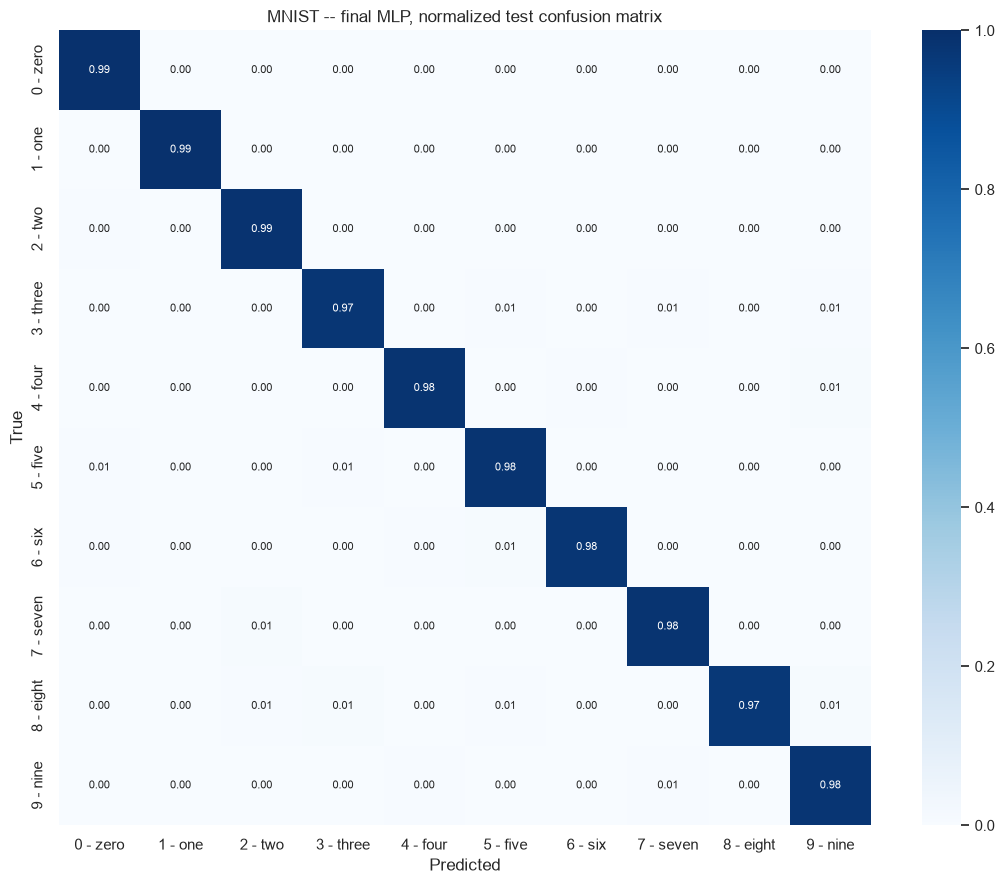

,true,predicted,count,share_of_true_class
35,6 - six,5 - five,11,0.011482
46,8 - eight,3 - three,10,0.010267
40,7 - seven,2 - two,10,0.009728
51,8 - eight,9 - nine,8,0.008214
25,4 - four,9 - nine,8,0.008147
17,3 - three,5 - five,7,0.006931
18,3 - three,7 - seven,7,0.006931
26,5 - five,0 - zero,6,0.006726


In [31]:
plot_confusion(
    mnist_test_metrics["y_true"], mnist_test_metrics["y_pred"], mnist_data["classes"],
    "MNIST -- final MLP, normalized test confusion matrix", "mnist_mlp_confusion_matrix.png"
)
mnist_errors = top_confusions(mnist_test_metrics["y_true"], mnist_test_metrics["y_pred"], mnist_data["classes"])
mnist_errors

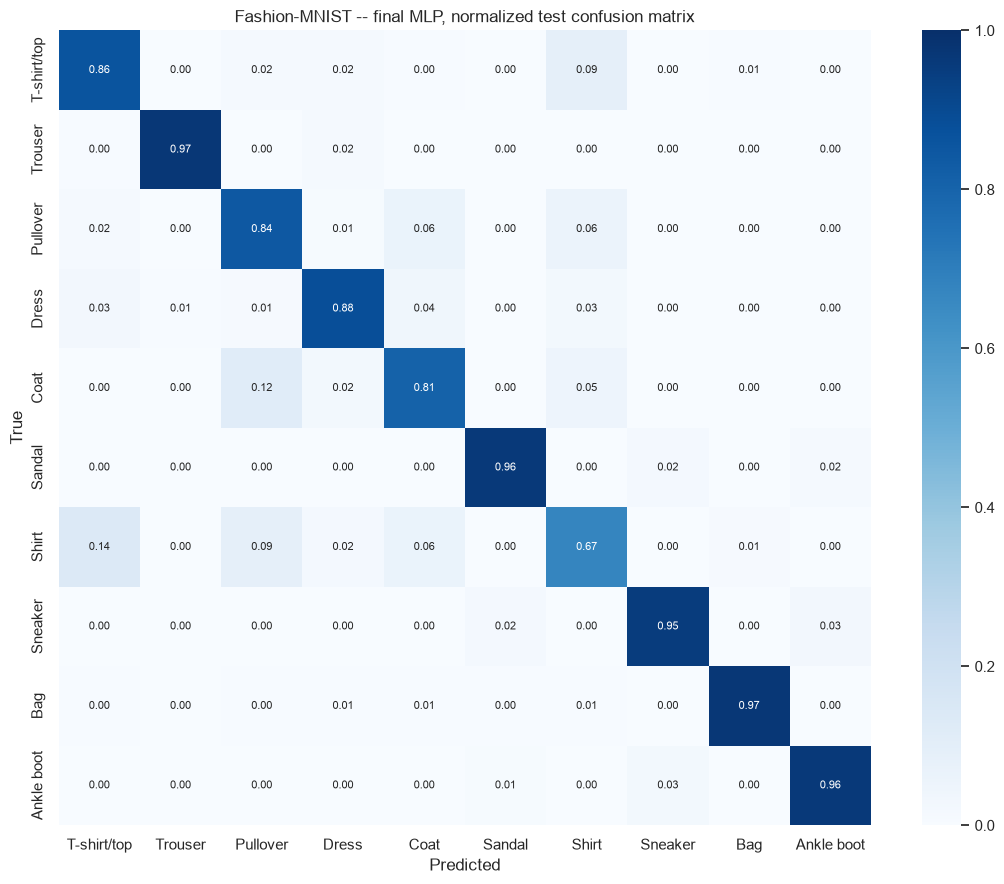

,true,predicted,count,share_of_true_class
32,Shirt,T-shirt/top,138,0.138
25,Coat,Pullover,115,0.115
33,Shirt,Pullover,91,0.091
4,T-shirt/top,Shirt,90,0.090
14,Pullover,Coat,63,0.063
35,Shirt,Coat,63,0.063
15,Pullover,Shirt,62,0.062
27,Coat,Shirt,52,0.052


In [18]:
plot_confusion(
    fashion_test_metrics["y_true"], fashion_test_metrics["y_pred"], fashion_data["classes"],
    "Fashion-MNIST -- final MLP, normalized test confusion matrix", "fashion_mlp_confusion_matrix.png"
)
fashion_errors = top_confusions(fashion_test_metrics["y_true"], fashion_test_metrics["y_pred"], fashion_data["classes"])
fashion_errors


## Анализ ошибок

_Таблицы выше автоматически сортируют самые частые **направленные** ошибки `true -> predicted`._

Для `Fashion-MNIST` изначально ожидал ошибки в парах верхней одежды (`Shirt`, `T-shirt/top`, `Pullover`, `Coat`): их силуэты довольно похожи.

`MNIST` же модель переварила значительно лучше: по метрикам все хорошо, _из [EDA](/notebooks/00_EDA.ipynb) вполне ожидаемо._

## Выводы

- слишком большая глубина вредна для сети, в то время как большая ширина просто перестает давать прирост;
- ожидания ошибок моделей, высказанные в [EDA](/notebooks/00_EDA.ipynb), подтвердились;
- нейронные сети достаточно хорошо справляются с поставленной задачей _(в рамках курса в универе уже работал с ней, действительно сложностей нет)_.
